Focus presentation for decision makers on why customers leave THE Chuurrrrrrnnn column

## Case Study

In [94]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, classification_report
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import seaborn as sns
from sklearn.feature_selection import SelectFromModel

In [133]:
df = pd.read_csv("customer_churn.csv")
df.head() #gender, dependents, partner, OnlineSecurity, DeviceProtection, 

,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,2,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [134]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [135]:
df.iloc[:, 13:]

,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,No,No,One year,No,Mailed check,56.95,1889.50,No
2,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...
7038,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [136]:
df.info() #gender, dependents, partner, OnlineSecurity (Ordinal), Contract(ordinal), DeviceProtection, PhoneService, MultipleLines (ordinal), InternetService (Ordinal), OnlineBackup (Ordinal), 
# DeviceProtection (ordinal), TechSupport(ord), StreamingTV(ord), StreamingMovies(ord), PaperlessBilling (cat), PaymentMethod (cat)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7043 non-null   int64  
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [137]:
df["Contract"].value_counts()


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [ ]:
X= df.drop(columns=["Churn", 'Unnamed: 0'], errors='ignore')
y= df['Churn']

In [139]:
#gender, dependents, partner, OnlineSecurity (Ordinal), Contract(ordinal), DeviceProtection, PhoneService, MultipleLines (ordinal), InternetService (Ordinal), OnlineBackup (Ordinal), 
# DeviceProtection (ordinal), TechSupport(ord), StreamingTV(ord), StreamingMovies(ord), PaperlessBilling (cat), PaymentMethod (cat)

In [140]:
# make list of cols
ord_cols=['Contract']

cat_cols=df.drop(columns=['Churn','Contract','MonthlyCharges', 'TotalCharges', 'tenure', 'Unnamed: 0']).columns.tolist()
num_cols=['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'PaymentMethod']

In [141]:
for col in df[cat_cols]:
    print(df[col].unique())

['Female' 'Male']
[0 1]
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['No phone service' 'No' 'Yes']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['Yes' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [142]:
fill_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ("num", StandardScaler())
])
preprocessor= ColumnTransformer(
    [
        ("ord", OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']], dtype=int), ord_cols),
        ("ohe", OneHotEncoder(sparse_output=False, drop='first'), cat_cols),
        ('num', fill_pipe, num_cols)
        
    ], remainder='passthrough'
)


In [143]:

from random import Random


pipe= Pipeline([
    ("preprocessor", preprocessor),
    ("RandomForestClassifier", RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42))
])

In [144]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
    )

In [145]:
pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('RandomForestClassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ord', ...), ('ohe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [148]:
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.83      0.92      0.87      1036
         Yes       0.68      0.49      0.57       373

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [156]:
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
feature_names.shape

(30,)

In [155]:
importances = pipe.named_steps['RandomForestClassifier'].feature_importances_
importances.shape

(30,)

In [159]:
feature_importances = pd.Series(importances, feature_names).sort_values(ascending=False)

In [161]:
feature_importances.head(15)

ord__Contract                                0.218033
num__tenure                                  0.161658
num__TotalCharges                            0.143109
ohe__InternetService_Fiber optic             0.088587
num__MonthlyCharges                          0.083813
ohe__PaymentMethod_Electronic check          0.049099
remainder__Unnamed: 0                        0.034140
ohe__OnlineSecurity_Yes                      0.027678
ohe__TechSupport_Yes                         0.020112
ohe__StreamingTV_No internet service         0.016217
ohe__TechSupport_No internet service         0.015974
ohe__PaperlessBilling_Yes                    0.014306
ohe__DeviceProtection_No internet service    0.013084
ohe__InternetService_No                      0.011974
ohe__StreamingMovies_No internet service     0.009661
dtype: float64

Without doing feature selection, these are the top 15 features that the model thinks are important. This means that when the decision trees split on these features, the groups become more pure (each group becomes more uniform in the churn value).

Now we can do feature selection to take out the less important features and then see how much importance the model puts on the remaining.

In [168]:
y_prob = pipe.predict_proba(X_test)[:,1]
y_prob

array([0.62087504, 0.07337418, 0.010343  , ..., 0.00996674, 0.04547779,
       0.52362891], shape=(1409,))

In [169]:
results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred,"Churn Probability": y_prob})

results.head(10)

,Actual,Predicted,Churn Probability
185,Yes,Yes,0.620875
2715,No,No,0.073374
3825,No,No,0.010343
1807,Yes,Yes,0.768478
132,No,No,0.037608
1263,Yes,No,0.281689
3732,No,No,0.058002
1672,No,No,0.020992
811,Yes,No,0.099172
2526,Yes,No,0.302237


Values closer to one indicate a customer more likely to churn (did not stay).  
Customers with probabilities above .5 could be flagged as high risk and prioritized for outreach or incentives

## feature selection

In [78]:
result= permutation_importance( 
    pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

In [83]:
feature_names = X_test.columns

In [84]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
15,Contract,0.025195
5,tenure,0.016466
8,InternetService,0.014336
18,MonthlyCharges,0.009013
17,PaymentMethod,0.005039
12,TechSupport,0.003833
16,PaperlessBilling,0.003478
2,SeniorCitizen,0.003407
9,OnlineSecurity,0.003194
7,MultipleLines,0.001916


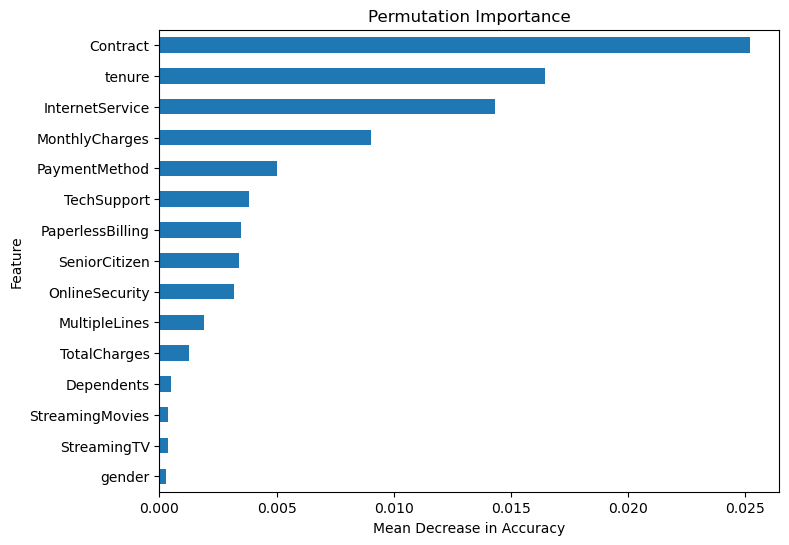

In [85]:
importance_df.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 6),
    legend=False
)

plt.title("Permutation Importance")
plt.xlabel("Mean Decrease in Accuracy")
plt.show()

Contract is the most important feature by far. Customers on month-tomonth contracts are much more liekly to churn than those on one or two year contracts.  
Tenure is the second most important feature- newer customers are more likely to leave (long-term) customers stay. 


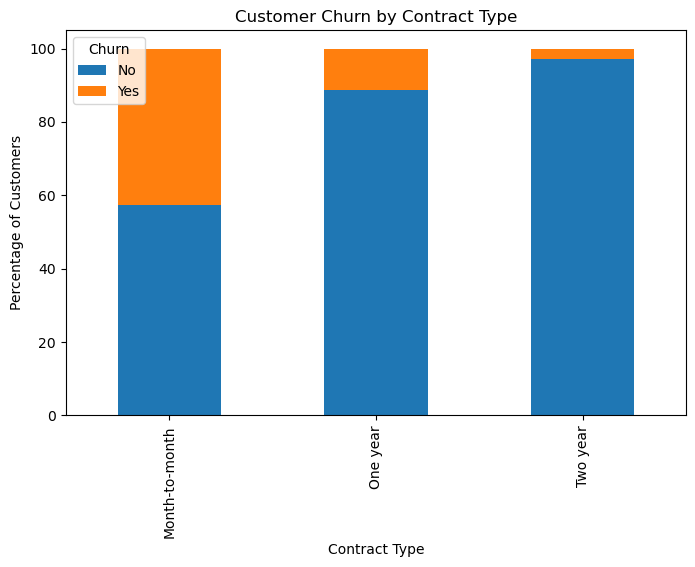

In [86]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.legend(title="Churn")
plt.show()

approximately 40% of month-to-month customers churned while the yearly contracts were less than 20%. Longer contracts reduce churn

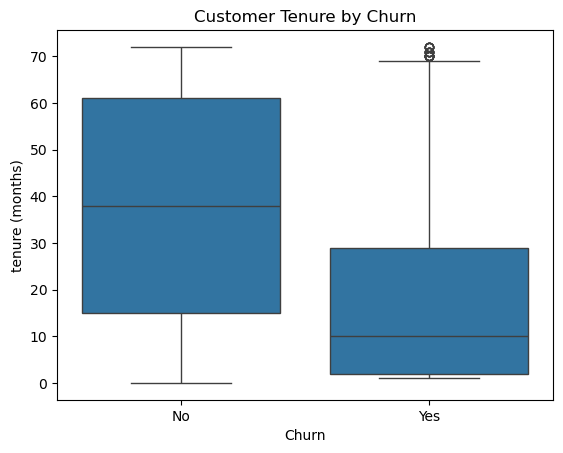

In [90]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)
plt.ylabel("tenure (months)")
plt.title("Customer Tenure by Churn")
plt.show()

In [91]:
df.groupby("Churn")["tenure"].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

Most customers who churn have low tenure (they haven't been customers for long). Customers who leave typically do so in the first few months. 
The median tenure of customers who churned was 10 months vs a median of 38 months for customers who did not churn. 